<a href="https://colab.research.google.com/github/isaactychique/data_classification/blob/ai-ml_project/notebook_TP_Snum2_2026_amorce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center>TP Data classification</center>
## <center>Neural networks - MNIST database

<center>
Pascal Scalart & Marie-Anne Lacroix<br>
2025-2026<br>
SNUM2 - Département Systèmes Numériques- ENSSAT Lannion<br> <br>



</center>




  # <center> Rapport sur la Classification de Données  </center>
  ## <center>    Etudiant: Sounsin Isaac Tychique  DAKIO   </center>





# <font color=blue>Stage 1 : Loading the database  </font>

In [ ]:
from keras.datasets import mnist

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#### Nous importons nos données du dataset MNIST en utilisant keras. Ce jeu de données que nous avons est constitué de 04 sous_ensemble : les données d'entraînement et de test(x_train et x_test) et les labels de test et d'entraînement (y_test et y_train). Les labels indiquent à quelle classe appartiennent nos images.

#### Nous affichons ensuite la dimension de nos sous_ensemble pour observer la structure de nos données.

#### On observe 60000 images d'entraînement et 10000 images pour les tests.On a des images de $28*28$ pixels.

In [ ]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


In [ ]:
from numpy import expand_dims

train_X = expand_dims(train_X, -1)
test_X = expand_dims(test_X, -1)

#### Nous avons affiché ici quelques images que contiennent les données d'entraînement. Nous remarquons que ce sont des images en noir et blanc qui représentent des chiffres.


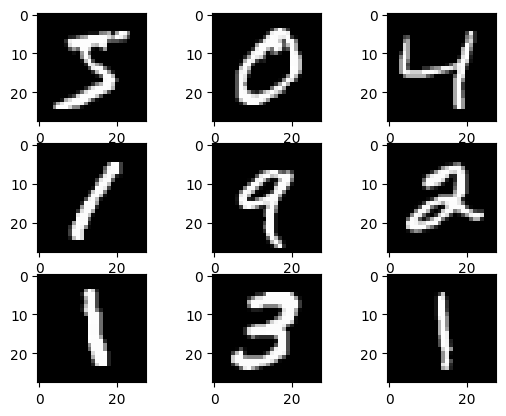

In [ ]:
import matplotlib.pyplot as plt

for i in range(9):
    plt.subplot(3,3,1 + i)
    plt.imshow(train_X[i], cmap=plt.get_cmap('gray'))
plt.show()

#### Ici, on a transformé nos labels d'entraînement et de tests en des matrices binaires avant de les faire passer en flottants codés sur 32bits qui facilite l'optimisation des calculs. La 1ere transformation c'est pour éviter que les réseaux pensent qu'il y'a une rélation d'ordre entre les classes.  Aussi, nous avons fait une normalisation pour obtenir des valeurs entre [0,1]. Cela nous facilite l'apprentissage.

In [ ]:
import keras

train_y = keras.utils.to_categorical(train_y, 10)
test_y = keras.utils.to_categorical(test_y, 10)

train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X /= 255
test_X /= 255

#### Nous avons fait une répartition de nos données entre celles qui seront utilisées pour entraîner et valider nos modèles. On dédie les 1/6 de nos données aux données de validation et les 5/6 aux données d'entraînement.
#### Pour une bonne répartition des données, nous avons utilisé l'hyperparamètre shuffle() qui assure un mélange aléatoire des données.

#### Les données de validation sont utilisées pour évaluer les performances du modèle pendant l'entraînement. Elles sont utilisées pour calculer le loss de validation et les autres métriques du modèle. Elles ne sont pas utilisées pour l'entraînement.


#### En sortie on voit donc que nous avons 50000 images pour le test et 10000 pour  la validation. Les images font $28*28$ pixels .

In [ ]:
from sklearn.model_selection import train_test_split

test_size = 5/6
valid_X, train_X, valid_y,train_y,  = train_test_split(train_X,train_y, test_size= test_size, shuffle=True, random_state=42)

print('X_train: ' + str(train_X.shape))
print('X_valid: '+ str(valid_X.shape))
print('X_test: ' + str(test_X.shape))

X_train: (50000, 28, 28, 1)
X_valid: (10000, 28, 28, 1)
X_test: (10000, 28, 28, 1)



#### Ces différentes fonctions sont celles définies et qui nous permettent de calculer les métriques de nos différents modèles à savoir le recall, la précision et le f1_score.

In [ ]:
import tensorflow.keras.backend as K

def recall_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

def precision_m(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

#### La fonction affichage est celle que nous utiliserons pour une représentation graphique des différentes métriques de nos modèles.

In [ ]:
def affichage(history):

    plt.figure(figsize=(15,12))

    # lecture accuracy
    plt.subplot(221)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='lower right')
    plt.grid()


    # lecture loss
    plt.subplot(222)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid()


    # lecture precision, recall, f-measure
    plt.subplot(223)
    plt.plot(history.history['precision_m'])
    plt.plot(history.history['recall_m'])
    plt.plot(history.history['f1_m'])
    plt.title('model precision, recall et f1-measure')
    plt.ylabel('%')
    plt.xlabel('epoch')
    plt.legend(['précision (training)', 'rappel (training)','mesure-f1 (training)'], loc='lower right')
    plt.grid()

        # lecture precision, recall, f-measure
    plt.subplot(224)
    plt.plot(history.history['val_precision_m'])
    plt.plot(history.history['val_recall_m'])
    plt.plot(history.history['val_f1_m'])
    plt.title('model precision, recall et f1-measure')
    plt.ylabel('%')
    plt.xlabel('epoch')
    plt.legend(['précision (val)', 'rappel (val)','mesure-f1 (val)'], loc='lower right')
    plt.grid()

    plt.show()



# <font color=blue>Stage 2: 1st network, multi-Layer Perceptron (MLP) with ReLu activation  </font>

#### Nous avons mis en place la structure de notre réseau de neurones. Dans la fonction que nous avons décrit, nous avons utilisé la fonction d'activation reLu() sur la 1ere couche cachée et le softmax() qui transforme les sorties en probabilités sur la couche de sortie. Aussi, nous avons utilisé le SGD() pour une mise à jour des poids de nos neurones.
#### Nous avons aussi fait une spécification des différentes métriques que nous allons observé pour évaluer les performances de notre modèle.
#### C'est l' accuracy, le F1 score, la precision et le recall.

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Activation
from keras.optimizers import SGD

def Net1(in_shape, layers, n_classes, lr):
  i = Input(shape=in_shape)
  x = Flatten()(i)

  for l in range(len(layers)):
    x = Dense(layers[l])(x)
    x = Activation('relu')(x)

  x = Dense(n_classes)(x)
  x = Activation('softmax')(x)

  model1 = Model(inputs=i, outputs=x)
  opt = SGD(learning_rate=lr, nesterov=False)
  model1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy', recall_m,
                                                                         precision_m, f1_m])

  return model1



#### Nous avons construit une réseau de neurone initial où nous avons 28*28 pixels pour chaque d'image qui forment un vecteur de $28*28*1 = 784$ descripteurs à l'entrée du réseau. L'image 2D is applati à l'entrée du réseau dans le but de présenter le vecteur de descripteurs(les pixels). Notre réseau est constitué de deux couches:


 #### *   Une couche d'entrée cachée de 30 neurones. Donc nous avons : $30*(1+784) = 23550$ paramètres (le "1" correspond au biais).

 ##### * Une couche de sortie of 10 neurones qui correspondent aux nombres de classes définies, avec $ 10*(1+30) = 310$ paramètres (le "1" correspond au biais).

#### En total, nous avons : $23.550 + 310 = 23.860 $ paramètres à ajuster



In [ ]:
lr = 0.2

in_shape = train_X.shape[1:]
n_classes = 10
layers = [30]

model1 = Net1(in_shape, layers, n_classes, lr)
model1.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

#### Nous avons entraîné notre modèle sur un sous_ensemble de 1000 images qui viennent des données d'entraînement et nous vérifions la validation sur les données de validation. Pour chaque époch, les images sont traités par mini_batches de 10 images.
#### Nous avons utilisé quelques hyperparamètres pour permettre à notre modèle de mieux performer. Nous avons notamment utilisé ici verbose = 1 qui nous permet de voir la barre de progression de l'entraînement de notre modèle. Il y'a également le shuffle() qui aide le modèle à ne apprendre dans un ordre particulier.
#### Aussi, nous avons utilisé le callbacks qui nous permet l'activation de early stopping. Ici nous avons mis la patience = 15 pour dire qu'au bout de 15epochs, si nous n'avons pas d'améliorations, on arrête le modèle.



In [ ]:
from keras.callbacks import EarlyStopping
train_x_net1 = train_X[:1000]
train_y_net1 = train_y[:1000]


early_stop = EarlyStopping(
    patience=15,
)


history1 = model1.fit(
    train_x_net1,
    train_y_net1,
    epochs=300,
    batch_size=10,
    validation_data=(valid_X, valid_y),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.4186 - f1_m: 0.2561 - loss: 1.7039 - precision_m: 0.5293 - recall_m: 0.1921 - val_accuracy: 0.7695 - val_f1_m: 0.7590 - val_loss: 0.7119 - val_precision_m: 0.8422 - val_recall_m: 0.6983
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8318 - f1_m: 0.8066 - loss: 0.5422 - precision_m: 0.8601 - recall_m: 0.7627 - val_accuracy: 0.8360 - val_f1_m: 0.8345 - val_loss: 0.5264 - val_precision_m: 0.8713 - val_recall_m: 0.8038
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9027 - f1_m: 0.8957 - loss: 0.3221 - precision_m: 0.9237 - recall_m: 0.8717 - val_accuracy: 0.8208 - val_f1_m: 0.8223 - val_loss: 0.6048 - val_precision_m: 0.8451 - val_recall_m: 0.8029
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9273 - f1_m: 0.9263 - loss: 0.2319 - precision_m: 0.9398 - recall_m: 0.9150 - val_accuracy: 0.8699 - val_f1_m: 0.8718 - val_loss: 0.4694 - val_precision_m: 0.8931 - val_r

#### En analysant les courbes, nous pouvons dire que nous sommes dans un cas d'overfitting. Notre modèle apprend bien sur les données d'entraînement mais ne généralise pas bien. On peut observer cela sur la courbe l'accucary de l'entraînement qui atteint vite la valeur 1. Cependant, on observe une constance plus basse pour l'accuracy de la validation qui est autour de 0.88.
#### Et aussi, le loss d'entraînement baisse jusqu'à 0 tandis que le loss de la validation augmente legèrement vers la fin. Donc notre modèle est en train de perdre sa capacité de généralisation.

#### Aussi, le recall, le f1 score et le précision converge pratiquement à 1 pour l'entrainement. Au niveau de la validation, ils sont des valeurs qui sont en dessous de 0.90. Cela montre que la performance du modèle est limitée sur de nouvelles données. Mais,on a une bonne précision du modèle en générale.



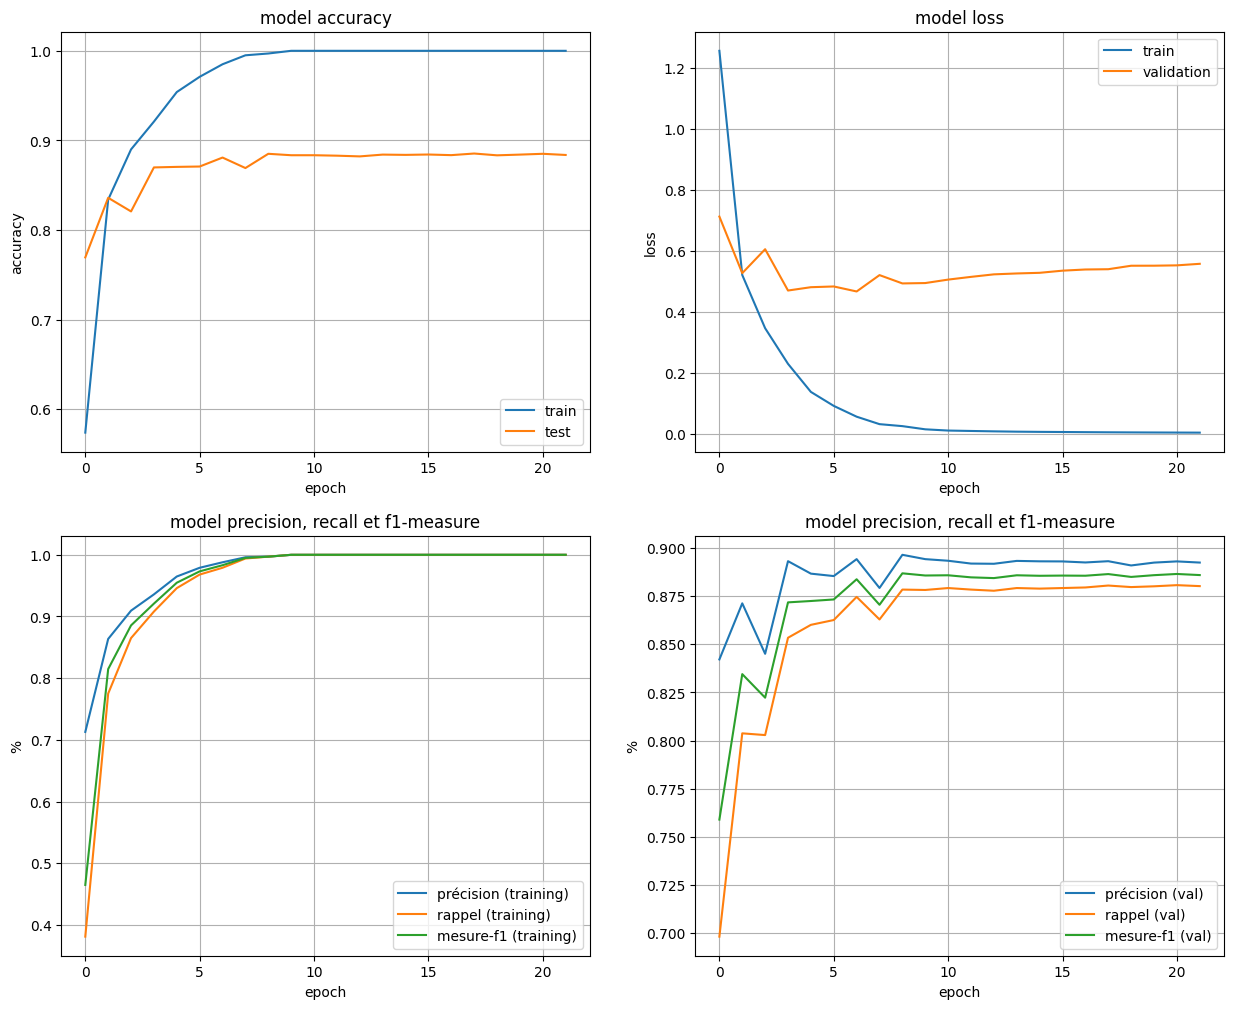

In [ ]:
hist1 = affichage(history1)

#### Les résultats du test nous donnne un accuracy de 89,46% ce qui est une bonne performance pour notre modèle. Nous avons tout de même un taux d'erreur de 10.54% qui n'est pas négligeable. En global, nous avons un bon score et le modèle detecte assez bien les différentes classes.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model1.evaluate(test_X, test_y,verbose=None)
print("Model n°1 - whole data processing (sgd) - accuracy (right prediction rate) : %.2f%%" % (scores[1]*100))
print("Model n°1 - whole data processing (sgd) - error rate : %.2f%%" % (100-scores[1]*100))

Model n°1 - whole data processing (sgd) - accuracy (right prediction rate) : 89.46%
Model n°1 - whole data processing (sgd) - error rate : 10.54%


# <font color=blue> A- Data augmentation </font>

#### Pour ce cas, nous avons augmenté la taille des données qui nous utilisons pour entraîner notre modèle. Nous sommes passés à 50.000 images.  Pour ce qui est du reste, nous avons gardé les mêmes caractéristiques. Donc nous aurons le même nombre de paramètres à ajuster pour ce cas.

In [ ]:
lr = 0.1
train_x_net1 = train_X
train_y_net1 = train_y
in_shape = train_X.shape[1:]
n_classes = 10
layers = [30]

model = Net1(in_shape, layers, n_classes, lr)
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

#### Pour l'entraînement du modèle, nous avons utilisé les mêmes paramètres. Juste que les données d'entraînement sont maintenants plus conséquentes. Nous avons aussi baissé le nombre d'epochs pour le mettre à 30 comme indiqué dans le tp.

In [ ]:

early_stop = EarlyStopping(patience=10)

history2 = model.fit(
    train_x_net1,
    train_y_net1, shuffle = True,
    epochs=30,
    batch_size=10,
    callbacks = [early_stop],
    validation_data=(valid_X , valid_y),
    verbose=1,
)

Epoch 1/30
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8633 - f1_m: 0.8442 - loss: 0.4475 - precision_m: 0.8948 - recall_m: 0.8149 - val_accuracy: 0.9394 - val_f1_m: 0.9398 - val_loss: 0.2018 - val_precision_m: 0.9496 - val_recall_m: 0.9312
Epoch 2/30
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9453 - f1_m: 0.9460 - loss: 0.1801 - precision_m: 0.9549 - recall_m: 0.9381 - val_accuracy: 0.9457 - val_f1_m: 0.9468 - val_loss: 0.1763 - val_precision_m: 0.9530 - val_recall_m: 0.9412
Epoch 3/30
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9581 - f1_m: 0.9586 - loss: 0.1416 - precision_m: 0.9645 - recall_m: 0.9534 - val_accuracy: 0.9448 - val_f1_m: 0.9463 - val_loss: 0.1697 - val_precision_m: 0.9532 - val_recall_m: 0.9402
Epoch 4/30
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9649 - f1_m: 0.9650 - loss: 0.1129 - precision_m: 0.9698 - recall_m: 0.9607 - val_accuracy: 0.9488 - val_f1_m: 0.9491 - val_loss: 0.1729 - val_precision_m: 0.9543 - v

#### En analysant les graphes de notre modèle avec l'augmentation de nos données, nous nous rendons compte que nous ne sommes plus dans un cas d'overfitting, il est bien contrôlé par rapport au premier car nous avons l'accuracy d'entraînement qui convergence lentement vers la valeur maximale de plus de 98%. L'accuracy de validation a une forte oscillation avec une valeur autour de 96%. Notre modèle se généralise bien dans ce cas grâce à une augmentation de nos données qui contraint notre modèle à apprendre plus sur les images.

#### On constate une décroissance beaucoup plus lisse de notre loss d'entrainement qui tend vers 0. Cependant le loss de validation est beaucoup plus instable et croît légèrement vers la fin montrant une tendance du modèle à vouloir surapprendre.

####Aussi, on constate que le recall, le f1 score et la précision sont très bonnes au niveau de l'entrainement avec une bonne convergence vers 0.98. Mais pour la validation, on constate une instabilité des courbes des métriques même s'ils ont de bonnes valeurs.

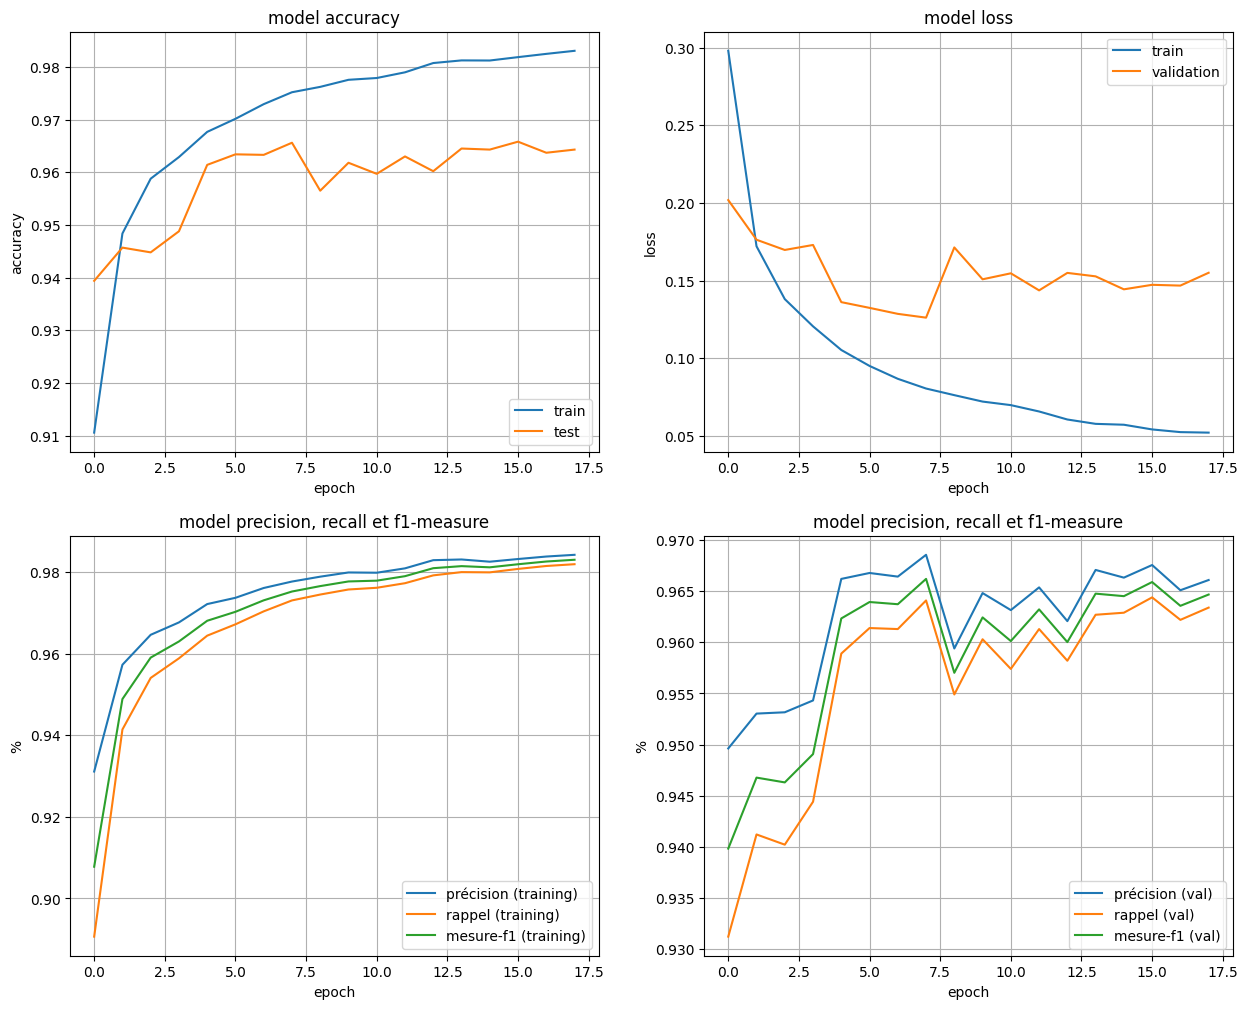

In [ ]:
hist2 = affichage(history2)

Nous avons un accuracy de 96.41% ce qui est une très bonne performance. On a une prédiction plus bonne que le modèle précédent. Nous avons tout de même une erreur de 3.59% qui n'est pas négligeable. Notre modèle donc se généralise assez bien sur les données de test et arrive à detecter très bien les différentes classes.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model.evaluate(test_X, test_y,verbose=None)
print("Model n°2 - whole data processing (sgd) - accuracy (right prediction rate) : %.2f%%" % (scores[1]*100))
print("Model n°2 - whole data processing (sgd) - error rate : %.2f%%" % (100-scores[1]*100))

Model n°2 - whole data processing (sgd) - accuracy (right prediction rate) : 96.41%
Model n°2 - whole data processing (sgd) - error rate : 3.59%


# <font color=blue> B- L2 regularization  </font>

#### Pour ce modèle, nous avons fait appel à la regularization L2. Cette méthode nous permet d'améliorer la généralisation lors de l'apprentissage et donc d'éviter le problème d'overfitting.
#### Nous allons donc dimunier les poids des neurones. Aussi cette méthode permet aussi d'accélerer l'apprentissage.
#### On utilise donc cette instruction :
#### kernel_regularizer=regularizers.L2(l2=0.01) pour appliquer cela à notre modèle.
#### Le reste des instructions dans notre fonction sont les même que celles que nous avons utilisé ci_dessus.


In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Activation
from keras.optimizers import SGD
from keras import layers , regularizers

def Net2(in_shape, layers, n_classes, lr):
  i = Input(shape=in_shape)
  x = Flatten()(i)

  for l in range(len(layers)):
    x = Dense(layers[l], kernel_regularizer=regularizers.L2(l2=0.01))(x)
    x = Activation('relu')(x)

  x = Dense(n_classes, kernel_regularizer=regularizers.L2(l2=0.01))(x)
  x = Activation('softmax')(x)

  model = Model(inputs=i, outputs=x)
  opt = SGD(learning_rate=lr, nesterov=False)
  model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy', recall_m,
                                                                         precision_m, f1_m])


  return model

#### Nous avons le même nombre de paramètres à ajuster ici vu que nous n'avons pas modifié le nombre de neurones et de couches que nous voulons utiliser.

In [ ]:
lr = 0.1
train_x_net1 = train_X[:1000]
train_y_net1 = train_y[:1000]
in_shape = train_X.shape[1:]
n_classes = 10
layers = [30]

model = Net2(in_shape, layers, n_classes, lr)
model.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

#### Pour entraîner le modèle, nous avons ramené le nombre d'epochs à 300 avec une stratégie de shuffle. Le reste des hyperparamètres sont les mêmes.

In [ ]:

early_stop = EarlyStopping(patience=10)

history3 = model.fit(
    train_x_net1,
    train_y_net1,
    shuffle = True,
    epochs=300,
    batch_size=10,
    callbacks = [early_stop],
    validation_data=(valid_X , valid_y),
    verbose=1,
)

Epoch 1/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4465 - f1_m: 0.2034 - loss: 2.3798 - precision_m: 0.4220 - recall_m: 0.1470 - val_accuracy: 0.8067 - val_f1_m: 0.7547 - val_loss: 1.3393 - val_precision_m: 0.9106 - val_recall_m: 0.6556
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8015 - f1_m: 0.7702 - loss: 1.2450 - precision_m: 0.8696 - recall_m: 0.6981 - val_accuracy: 0.8265 - val_f1_m: 0.8077 - val_loss: 1.1628 - val_precision_m: 0.9032 - val_recall_m: 0.7385
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8507 - f1_m: 0.8331 - loss: 1.0393 - precision_m: 0.9263 - recall_m: 0.7674 - val_accuracy: 0.8638 - val_f1_m: 0.8466 - val_loss: 1.0198 - val_precision_m: 0.9251 - val_recall_m: 0.7869
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8860 - f1_m: 0.8572 - loss: 0.9349 - precision_m: 0.9265 - recall_m: 0.8044 - val_accuracy: 0.8525 - val_f1_m: 0.8422 - val_loss: 0.9895 - val_precision_m: 0.9166 - val_r

#### En analysant les graphes de la regularization L2, on remarque que nous n'avons pas le cas d'overfitting. Car notre modèle n'a pas un accuracy qui tend très rapidement vers 1. L'accuracy de l'entrainement et de la validation ont de forte oscillation mais reste tout de même constant dans une certaine plage de valeurs. L'accuracy de validation est un peu plus basse que celui de l'entrainement qui est autour de 0.95. Notre  modèle a une bonne généralisation et on a une dimunition de la mémorisation des données d'entrainement.

#### Le loss pour l'entrainement et la validation décroissent progressivement pour se stabiliser. Le modèle est devenu plus stable.  Le loss de test est un peu plus grande que celui du test. Le modèle est plus stable.

#### Les métriques pour l'entraînement ont une bonne convergence vers des valeurs situées environ entre 90 et 97%. Au niveau de la validation, nous avons une grande précision avec un recall et un f1 score un peu en dessous.


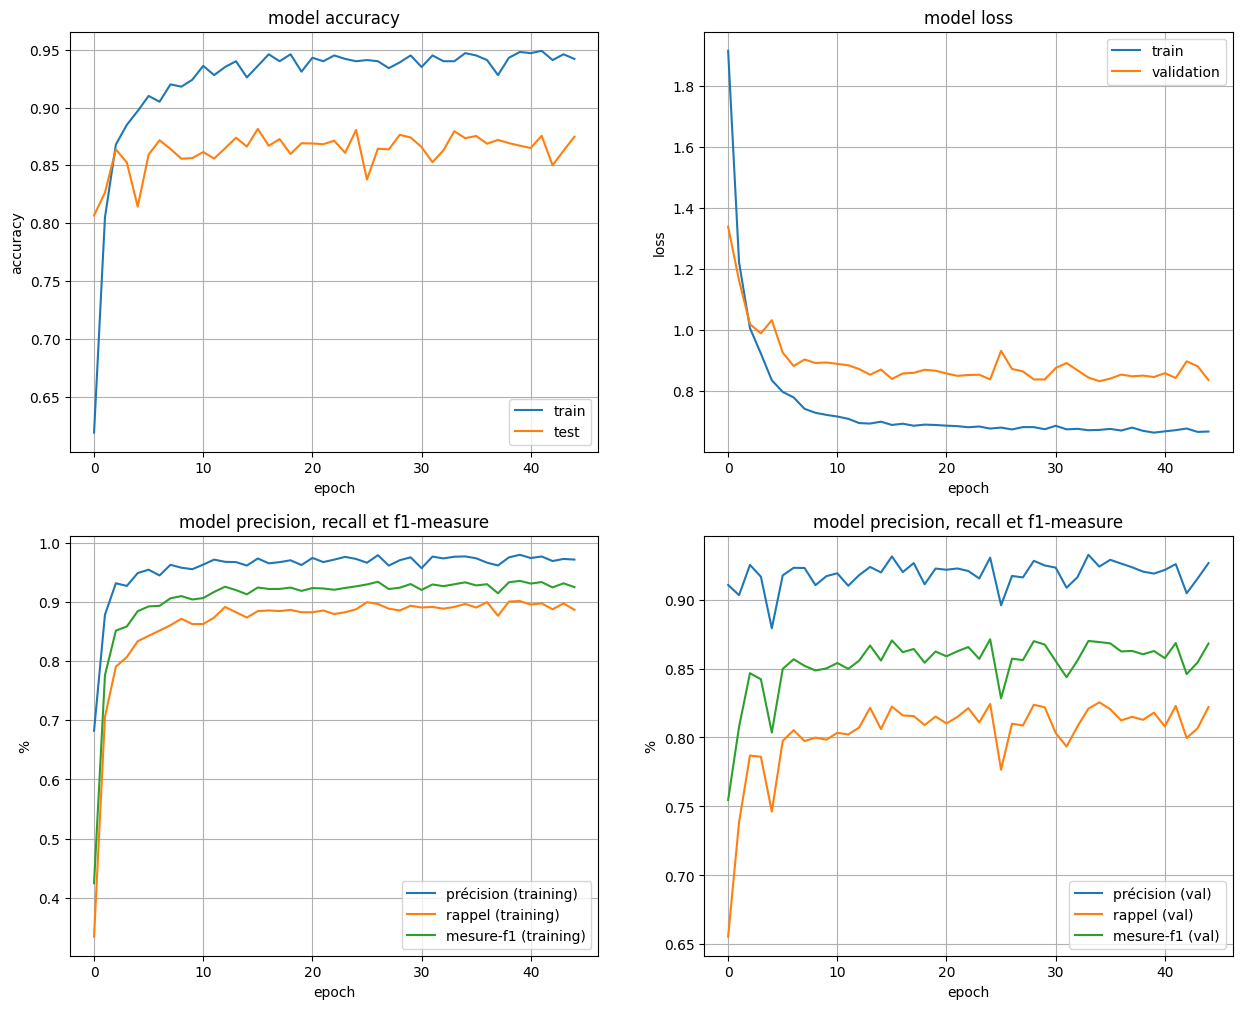

In [ ]:
hist3 = affichage(history3)

#### En evaluant le modèle, nous avons un bon score de 88.42% avec une marge d'erreur de 11.58%. Elle est un peu plus basse que le modèle précédent mais néanmoins, la généralisation du modèle est bonne. Ce modèle est plus stable et la prédiction des différentes classes est bonne.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model.evaluate(test_X, test_y,verbose=None)
print("Model n°3 - whole data processing (sgd) - accuracy (right prediction rate) : %.2f%%" % (scores[1]*100))
print("Model n°3 - whole data processing (sgd) - error rate : %.2f%%" % (100-scores[1]*100))

Model n°3 - whole data processing (sgd) - accuracy (right prediction rate) : 88.42%
Model n°3 - whole data processing (sgd) - error rate : 11.58%


# <font color=blue>C- DropOut </font>

#### Le Dropout est une technique de regularisation. Dans le cas du Dropout, nous allons désactiver de façon aléatoire certains neurones au niveau de la 1ere couche cachée qui contient 30 neurones. Et il se fait que pendant l'entraînememt. Nous allons désactiver 10% de nes neurones avec l'instruction:  x = Dropout(0.1)(x).

In [ ]:
from keras.layers import Dropout
def Net3(in_shape, layers, n_classes, lr):
  i = Input(shape=in_shape)
  x = Flatten()(i)

  for l in range(len(layers)):
    x = Dense(layers[l])(x)
    x = Activation('relu')(x)
    x = Dropout(0.1)(x)

  x = Dense(n_classes)(x)
  x = Activation('softmax')(x)

  model = Model(inputs=i, outputs=x)
  opt = SGD(learning_rate=lr, nesterov=False)
  model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy', recall_m,
                                                                         precision_m, f1_m])


  return model

#### Nous avons toujours les mêmes paramètres à ajuster vu que nous n'avons fait de modification sur le nombre de couches et de neurones. Et pour ce modèle, on garde 1000 données d'entraînement.

In [ ]:
lr = 0.1
train_x_net1 = train_X[:1000]
train_y_net1 = train_y[:1000]
in_shape = train_X.shape[1:]
n_classes = 10
layers = [30]

model = Net3(in_shape, layers, n_classes, lr)
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,860 (93.20 KB)

 Trainable params: 23,860 (93.20 KB)

 Non-trainable params: 0 (0.00 B)

#### Pour entraîner le modèle, nous avons garder les mêmes hyperparamètres.

In [ ]:

early_stop = EarlyStopping( patience=10)

history4 = model.fit(
    train_x_net1,
    train_y_net1,
    shuffle = True,
    epochs=300,
    batch_size=10,
    callbacks = [early_stop],
    validation_data=(valid_X , valid_y),
    verbose=1,
)

Epoch 1/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4456 - f1_m: 0.2184 - loss: 1.6710 - precision_m: 0.4145 - recall_m: 0.1622 - val_accuracy: 0.7631 - val_f1_m: 0.7384 - val_loss: 0.7099 - val_precision_m: 0.8486 - val_recall_m: 0.6618
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7939 - f1_m: 0.7724 - loss: 0.6509 - precision_m: 0.8676 - recall_m: 0.7016 - val_accuracy: 0.8616 - val_f1_m: 0.8561 - val_loss: 0.4895 - val_precision_m: 0.9181 - val_recall_m: 0.8076
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8531 - f1_m: 0.8398 - loss: 0.4555 - precision_m: 0.8976 - recall_m: 0.7939 - val_accuracy: 0.8625 - val_f1_m: 0.8617 - val_loss: 0.4623 - val_precision_m: 0.9026 - val_recall_m: 0.8281
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9064 - f1_m: 0.9002 - loss: 0.3125 - precision_m: 0.9272 - recall_m: 0.8774 - val_accuracy: 0.8783 - val_f1_m: 0.8774 - val_loss: 0.4218 - val_precision_m: 0.9155 - val_r

####Nous pouvons remarquer que l'accuracy d'entraînement a une bonne convergence et elle se stabilise autour de 98%. Nous n'avons pas d'overfitting mais la validation est stable autour de 88%. Nous avons un écart entre la validation et l'entraînement mais le dropout nous permet un bon apprentissage et une meilleure généralisation.
####Le loss d'entraînement decroît legèrement et se stabilise. On a un loss de validation qui est beaucoup plus stable mais un peu plus grande de celui de l'entrainement..

#### On constate que le recall, le F1 score et la précision sont beaucoup plus stables au moment de l'entrainement qu'au moment de la validation. Mais on a un bon équilibre.

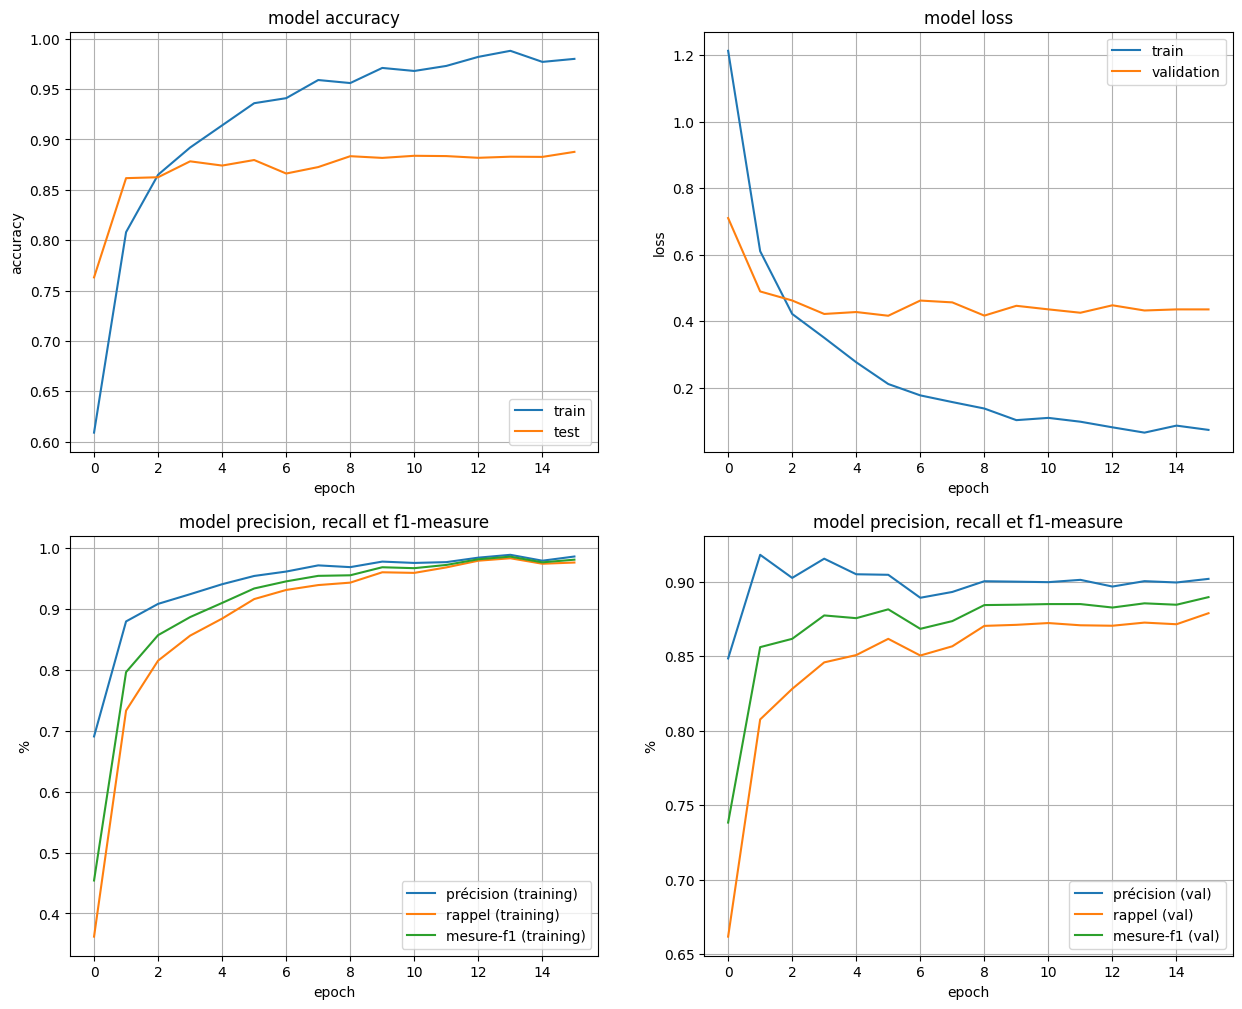

In [ ]:
hist4 = affichage(history4)

#### En évaluant notre modèle, nous avons un accuracy de 89.56%. Cela est un bon score. Le modèle a une bonne généralisation même si on a un taux d'erreur de 10.44%. On peut améliorer cette performance en jouant sur le taux de dropout.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model.evaluate(test_X, test_y,verbose=None)
print("Model n°4 - whole data processing (sgd) - accuracy (right prediction rate) : %.2f%%" % (scores[1]*100))
print("Model n°4 - whole data processing (sgd) - error rate : %.2f%%" % (100-scores[1]*100))

Model n°4 - whole data processing (sgd) - accuracy (right prediction rate) : 89.56%
Model n°4 - whole data processing (sgd) - error rate : 10.44%


#### En observant la matrice de confusion, nous pouvons remarquer que les scores sur la diagonale sont très grandes. Ils sont entre 0.84 et 0.97. Donc notre modèle identifie correctement la classe correspondante dans plus de 80% des cas et cela est une bonne performance. Toutes les différentes classes ont un très bon taux de prédiction même si nous avons des petites erreurs.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


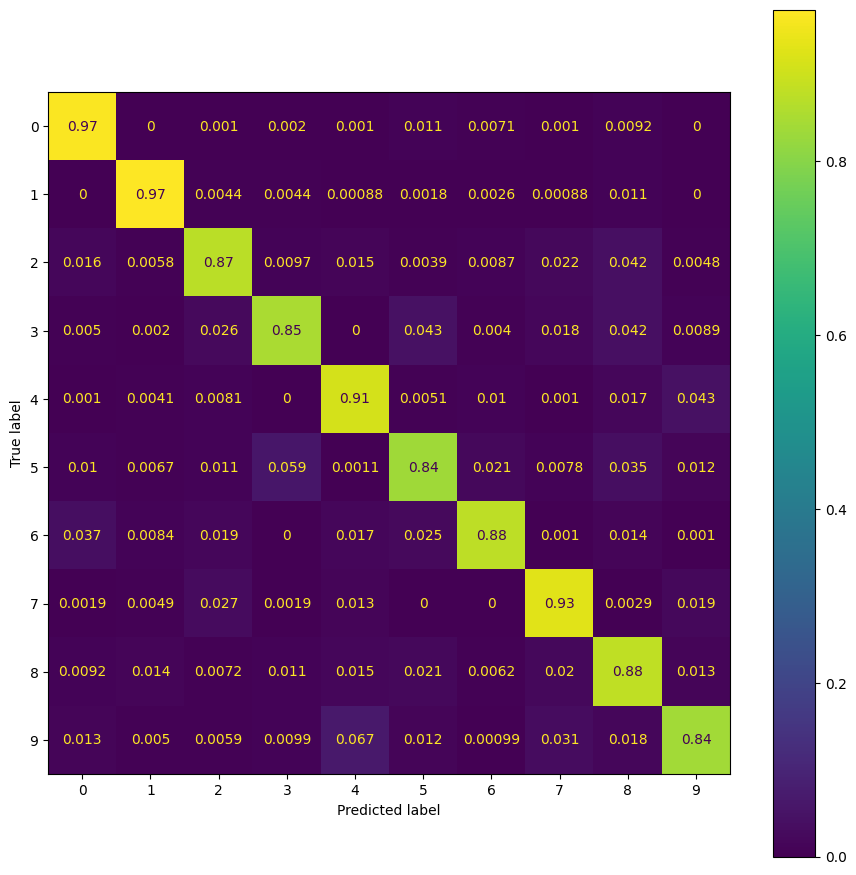

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       980
           1       0.96      0.97      0.97      1135
           2       0.89      0.87      0.88      1032
           3       0.90      0.85      0.88      1010
           4       0.87      0.91      0.89       982
           5       0.86      0.84      0.85       892
           6       0.93      0.88      0.91       958
           7       0.90      0.93      0.92      1028
           8       0.82      0.88      0.85       974
           9       0.89      0.84      0.86      1009

    accuracy                           0.90     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
%matplotlib inline
prediction_y = model.predict(test_X)
pred_y = np.argmax(prediction_y, axis = 1)
cm = confusion_matrix(np.argmax(test_y,axis = 1),pred_y, normalize='true')
plt.rcParams['figure.figsize'] = [11, 11]
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1,2,3,4,5,6,7,8,9])
disp.plot()
plt.show()
print(classification_report(np.argmax(test_y,axis = 1),pred_y))

# <font color=blue>Stage 3: 2nd network, CNN  </font>

#### Nous avons mis en place la fonction qui nous permet de construire notre premier réseau de neurones convolutif(CNN). Nous allons donc conserver la structure 2D de notre image avec Conv2D() au lieu de l'aplatir. Nous chercherons donc les motifs qui nous permettrons de reconnaître les images.
#### Nous avons la fonction suivante qui nous permet de faire cela.  On a utilisé le GlobalMaxPooling2D() qui nous permet de garder la valeur maximale détectée  pour chaque filtre sur toute l'image.
#### Nous appliquons pour notre cas des filtres de taille $(3*3)$.

#### On utilise aussi l'optimiseur Adam et la fonction sofmax en sortie pour permettre une bonne classification multi-classe.

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Activation
from keras.optimizers import Adam, SGD
from keras.layers import Conv2D, GlobalMaxPooling2D


def ConvNet1(in_shape, layers, n_classes):
    i = Input(shape=in_shape)

    for n in range(len(layers)):
        if n == 0:
            x = Conv2D( layers[n], kernel_size=(3,3), strides=(1,1),padding="same")(i)  # définition de la 1ère couche avec i entrée
        else:
            x = Conv2D(layers[n], kernel_size=(3,3), strides=(1,1),padding="same")(x)  # définition des couches suivantes avec x en entrée
        x = Activation('relu')(x)

    x = GlobalMaxPooling2D()(x)
    x = Dense(n_classes)(x)
    x = Activation('softmax')(x)

    model = Model(inputs=i, outputs=x)
    opt = Adam()
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy', f1_m, precision_m, recall_m ]) # we add our new metrics in the compilation

    return model

#### Nous avons construit une réseau de neurones convolutif où nous avons 28*28 pixels pour chaque d'image qui forment un vecteur de $28*28*1 = 784$ descripteurs à l'entrée du réseau. L'image 2D est conservé sous forme matricielle 2D ($28, 28, 1$) pour préserver les relations spatiales. Notre réseau est constitué de trois couches de convolution Conv2D:
 #### *   La 1ere couche utilise  30 filtres. Donc nous avons :$30*(1+3*3) = 300$ paramètres.

 #### * La 2eme couche utilisent 40 filtres qui sont liés aux 30 précédents. Nous avons donc : $40*(1 + 3*3*30) = 10.840$ paramètres.
 #### * La 3eme couche utilise 50 filtres : $ 50 * (1+ 3*3*40) = 18.050 $ paramètres.

 #### * Nous avons une couche de GlobalMaxPooling qui réduit les caractéristiques à un vecteur de 50 descripteurs. Donc nous avons 0paramètre.
 #### * Et nous avons la couche de sortie : Nous avons 10 neurones(un neurone par classe). Donc nous avons : $10*(1+50) = 510 $ paramètres
#### En total, nous avons : $300 + 10.840 + 18.050 + 510 = 29.7000 $ paramètres à ajuster



In [ ]:

lr = 0.1
train_x_net1 = train_X
train_y_net1 = train_y
in_shape = train_X.shape[1:]
n_classes = 10
layers = [30, 40, 50]


model = ConvNet1(in_shape, layers, n_classes)
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 30)     │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 28, 28, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 40)     │        10,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 28, 28, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 50)     │        18,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 28, 28, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 50)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,700 (116.02 KB)

 Trainable params: 29,700 (116.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Nous avons entraîné notre modèle en gardant un nombre d'epochs à seulement 10 et en gardant les autres hyperparamètres inchangés.


In [ ]:

early_stop = EarlyStopping( patience=5)

history5 = model.fit(
    train_x_net1,
    train_y_net1,
    shuffle = True,
    epochs=10,
    batch_size=10,
    callbacks = [early_stop],
    validation_data=(valid_X , valid_y),
    verbose=1,
)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.7940 - f1_m: 0.7474 - loss: 0.6160 - precision_m: 0.8116 - recall_m: 0.7171 - val_accuracy: 0.9544 - val_f1_m: 0.9558 - val_loss: 0.1447 - val_precision_m: 0.9626 - val_recall_m: 0.9497
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9625 - f1_m: 0.9627 - loss: 0.1139 - precision_m: 0.9682 - recall_m: 0.9578 - val_accuracy: 0.9676 - val_f1_m: 0.9673 - val_loss: 0.1080 - val_precision_m: 0.9725 - val_recall_m: 0.9627
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9720 - f1_m: 0.9727 - loss: 0.0843 - precision_m: 0.9765 - recall_m: 0.9693 - val_accuracy: 0.9762 - val_f1_m: 0.9770 - val_loss: 0.0811 - val_precision_m: 0.9802 - val_recall_m: 0.9742
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9767 - f1_m: 0.9767 - loss: 0.0707 - precision_m: 0.9793 - recall_m: 0.9744 - val_accuracy: 0.9783 - val_f1_m: 0.9780 - val_loss: 0.0738 - val_precision_m: 0.9803 - v

#### En analysant les graphes, nous remarquons que les réseaux de neurones convolutifs sont plus précis et plus performants. Nous avons un accuracy d'entrainement et de validation qui ont une bonne croissance et sont autour de 98%. Au niveau du loss, nous voyons que pour l'entrainement, il y'a une décroissance progressive qui se stabilise à une valeur qui tend vers 0. Pour le loss de validation, on constate une légère oscillation qui décroît vers la fin. Notre modèle a une très bonne généralisation et est aussi stable.  

#### Aussi, le recall, la précision et le F1 score qui ont également une bonne convergence pour l'entrainement mais ils oscillent beaucoup pendant la validation même s'ils ont de bonne valeurs.

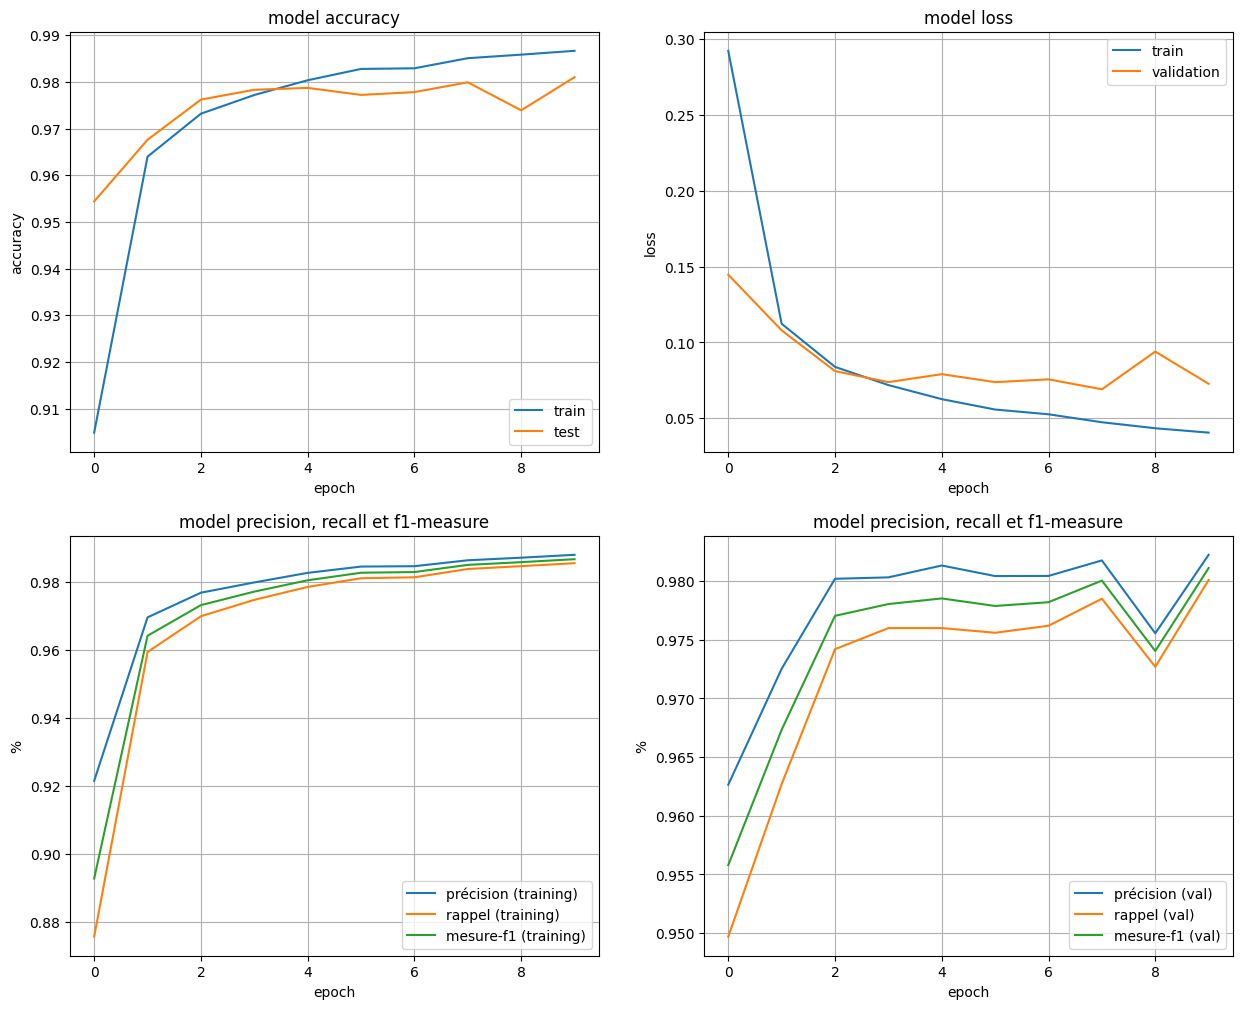

In [ ]:
hist5 = affichage(history5)


#### En évaluant le modèle, on se rend compte que l'accuracy est de 98.37%. Ce qui est très considérable et démontre que notre modèle est très performant. Nous avons une erreur de 1.63% pour notre modèle. Ce taux d'erreur n'est pas considérable. Donc pour détecter les différents classes auxquelles appartiennent nos images, le modèle performe très bien.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model.evaluate(test_X, test_y,verbose=None)
print("Model n°5 - Conv 2 with mini-batch processing - accuracy: %.2f%%" % (scores[1]*100))
print("Model n°5 - Conv 2 with mini-batch processing - error rate: %.2f%%" % (100-scores[1]*100))

Model n°5 - Conv 2 with mini-batch processing - accuracy: 98.37%
Model n°5 - Conv 2 with mini-batch processing - error rate: 1.63%


#### En observant la matrice de confusion, nous voyons bien une très bonne prédiction de nos différentes classes avec une marge d'erreur qui est très faible. Les prédictions sont entre 97 et 100%. Ce qui est un très bon ratio.
#### Notre modèle arrive à détecter assez correctement les différentes classes.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


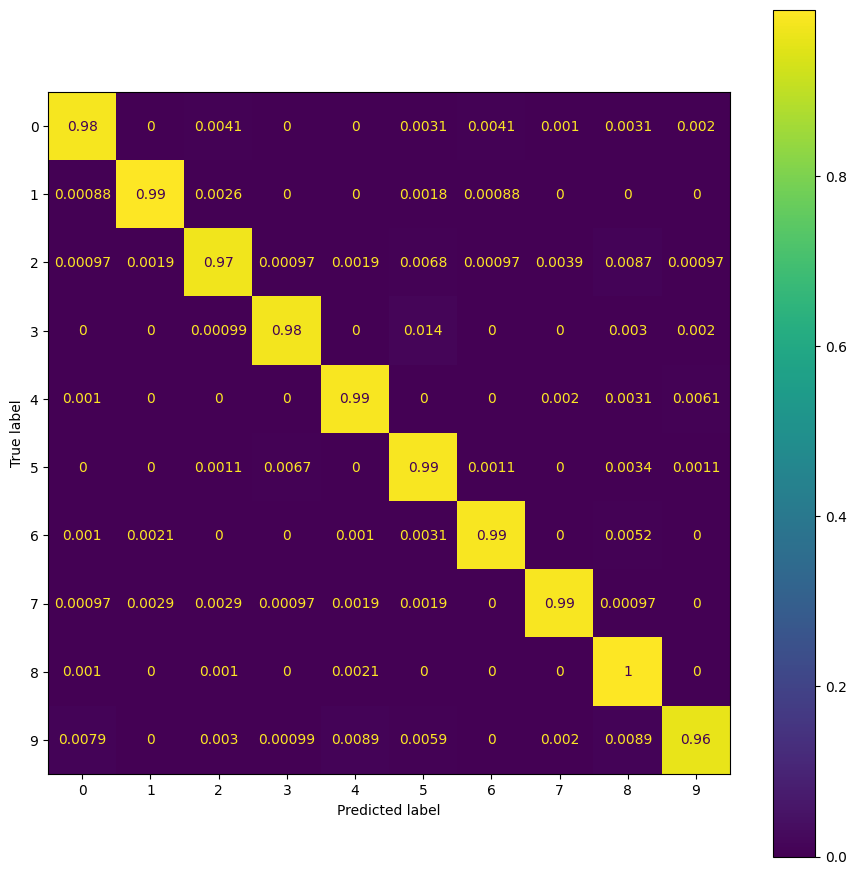

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.96      0.99      0.97       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.96      1.00      0.98       974
           9       0.99      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
%matplotlib inline
prediction_y = model.predict(test_X)
pred_y = np.argmax(prediction_y, axis = 1)
cm = confusion_matrix(np.argmax(test_y,axis = 1),pred_y, normalize='true')
plt.rcParams['figure.figsize'] = [11, 11]
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1,2,3,4,5,6,7,8,9])
disp.plot()
plt.show()
print(classification_report(np.argmax(test_y,axis = 1),pred_y))

# <font color=blue>Stage 4: 3rd network, CNN  with normalization </font>

#### Nous avons appliqué à notre réseau de neurones convolutifs, la normalisation et le flatten à la fin. Nous avons donc appliqué la BatchNormalization() qui permet de normaliser les sorties de chaque couche pour qu'elles aient une moyenne de 0 et un écart type 1. On preserve ainsi la stabilité du modèle de même qu'un taux d'apprentissage élevé.

#### Aussi, avant la prise de décision, nous avons fait un Flatten en lieu et place du GlobalMaxPooling pour permettre de garder toutes les informations finales avant de prendre une décision sur les 10 classes.  

In [ ]:
from keras.layers import BatchNormalization, MaxPooling2D

def ConvNet2(in_shape, layers, n_classes):
  i = Input(shape = in_shape)
  x = i
  for n in range(len(layers)):
    if n == 0 :
      x = Conv2D(layers[n], kernel_size = (3,3), strides = (1,1), padding = "same")(x)
      x = BatchNormalization()(x)
      x = MaxPooling2D(pool_size = (2,2), strides = (2,2))(x)
    else :
      x = Conv2D(layers[n], kernel_size = (3,3), strides = (1,1), padding = "same")(x)
      x = Activation('relu')(x)
      x = BatchNormalization()(x)
      x = MaxPooling2D(pool_size = (2,2), strides = (2,2))(x)

  x = Flatten()(x)
  o = Dense(n_classes , activation='softmax')(x)

  model = Model(inputs = i, outputs = o)
  opt = Adam(learning_rate=2e-3)
  model.compile(loss = 'categorical_crossentropy', optimizer = opt,
                metrics = ['accuracy',f1_m, precision_m, recall_m])

  return model

#### Pour trouver le nombre de paramètres à ajuster, nous avons ici 3 couches de convolution:

#### * La 1ere couche avec 20filtres, nous avons : $ 20 *(1+ 3*3*1) = 200$ paramètres.  Ell est suivie d'une BatchNormalization qui ajoute $20*4 = 80$ paramètres.

#### * La 2eme couche avec 30 filtres qui sont liés aux 20précédents, nous avons : $ 30 *(1+ 3*3*20) = 5.430 $ paramètres.
#### * La 3eme couche avec 65 filtres liés aux 30 précédents, nous avons : $ 65 *(1+ 3*3*30) = 17.615$ paramètres.
#### * Sa BatchNormalization ajoute  $ 65 *4 = 260$ paramètres.

#### * En faisant le flatten, nous avons $3*3*65 = 585 $ descripteurs donc 0 paramètre.

#### * La couche de sortie qui comporte 10neurones pour la classification finale. Nous avons : $10*(1+585) = 5860$ paramètres.

#### Nous avons au total : $ 200 + 80 + 5430 + 120 + 17615 + 260 + 5860 = 29565 $ paramètres à ajuster.


In [ ]:
lr = 0.1
train_x_net1 = train_X
train_y_net1 = train_y
in_shape = train_X.shape[1:]
print(in_shape)
n_classes = 10
layers = [20, 30, 65]


model = ConvNet2(in_shape, layers, n_classes)
model.summary()


(28, 28, 1)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 20)     │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 30)     │         5,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 14, 14, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 30)     │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 65)       │        17,615 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 7, 7, 65)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 65)       │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 65)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 585)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,565 (115.49 KB)

 Trainable params: 29,335 (114.59 KB)

 Non-trainable params: 230 (920.00 B)

#### Nous entraînons le modèle avec un nombre d'epochs de 10. Et notre batch_size, nous le faisons passés à 32.

In [ ]:
# Early Stopping Configuration
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training execution
history_6 = model.fit(
    train_X, train_y,
    epochs=10,
    batch_size=32,
    validation_data=(valid_X , valid_y),
    callbacks=[early_stopping]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9287 - f1_m: 0.9279 - loss: 0.2443 - precision_m: 0.9416 - recall_m: 0.9167 - val_accuracy: 0.9743 - val_f1_m: 0.9742 - val_loss: 0.0855 - val_precision_m: 0.9760 - val_recall_m: 0.9724
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9832 - f1_m: 0.9836 - loss: 0.0539 - precision_m: 0.9850 - recall_m: 0.9824 - val_accuracy: 0.9789 - val_f1_m: 0.9791 - val_loss: 0.0759 - val_precision_m: 0.9806 - val_recall_m: 0.9776
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - f1_m: 0.9883 - loss: 0.0390 - precision_m: 0.9889 - recall_m: 0.9878 - val_accuracy: 0.9818 - val_f1_m: 0.9817 - val_loss: 0.0624 - val_precision_m: 0.9828 - val_recall_m: 0.9807
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9894 - f1_m: 0.9895 - loss: 0.0308 - precision_m: 0.9900 - recall_m: 0.9891 - val_accuracy: 0.9876 - val_f1_m: 0.9878 - val_loss: 0.0487 - val_precision_m: 0.9880 - val_

#### En analysant les différents graphes, on constate que l'accuracy pour l'entraînement est convergente avec une bonne croissance qui atteint presque 1. Celui de la validation oscille beaucoup même s'il se trouve dans une bonne plage de valeurs. Notre modèle a une très bonne généralisation.
#### Nous avons le loss d'entraînement et de validation qui ont une décroissance qui se stablise vers la fin autour de valeurs qui sont très proches de 0. Mais le loss de la validation a une forte oscillation.

#### Le recall, le f1 score et la précision sont très bonnes ici. Nous avons une forte convergence de ces derniers qui se stabilisent autour de 99% pour le test. Pour la validation nous avons une forte oscillation également. Mais on peut constater que le modèle est plus performant.

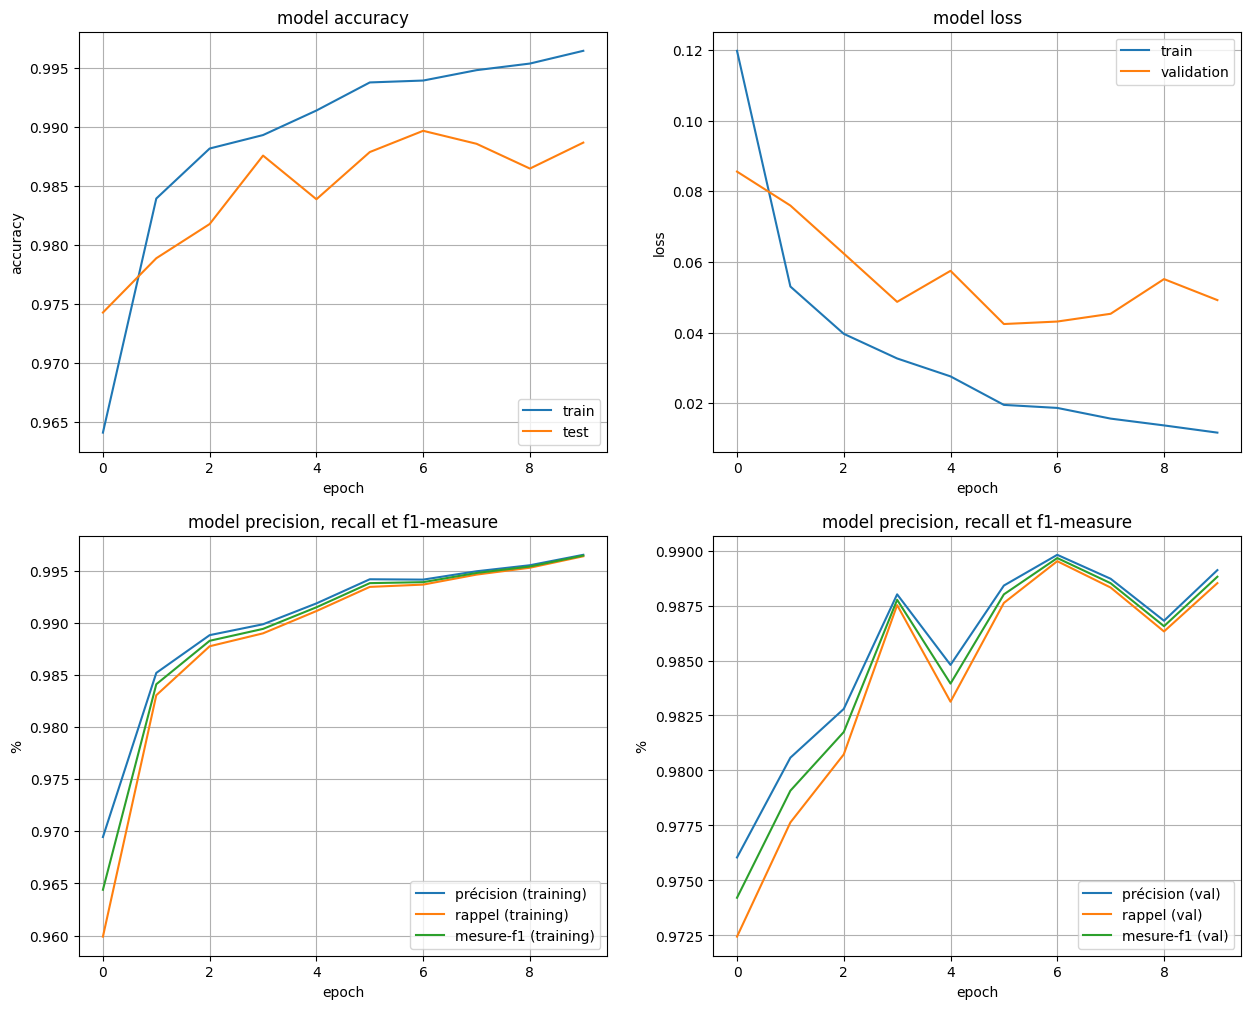

In [ ]:
hist6 = affichage(history_6)

#### L'évaluation du modèle nous donne un accuracy de 99.01%. Ce qui est un très bon ratio pour notre modèle. Les prédictions sont très précises avec l'ajout du BatchNormalization.

In [ ]:
# Test : The latest results obtained in the "validation" phase for the last epoch are shown below.
scores = model.evaluate(test_X, test_y,verbose=None)
print("Model n°6 - Conv 2 with mini-batch processing - accuracy: %.2f%%" % (scores[1]*100))
print("Model n°6 - Conv 2 with mini-batch processing - error rate: %.2f%%" % (100-scores[1]*100))

Model n°6 - Conv 2 with mini-batch processing - accuracy: 99.01%
Model n°6 - Conv 2 with mini-batch processing - error rate: 0.99%


La matrice de confusion nous donne une très bonne description de nos performances. Nous avons des bonnes prédictions par classe qui sont entre 98 et 100%. Ce qui est considérable pour notre modèle.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


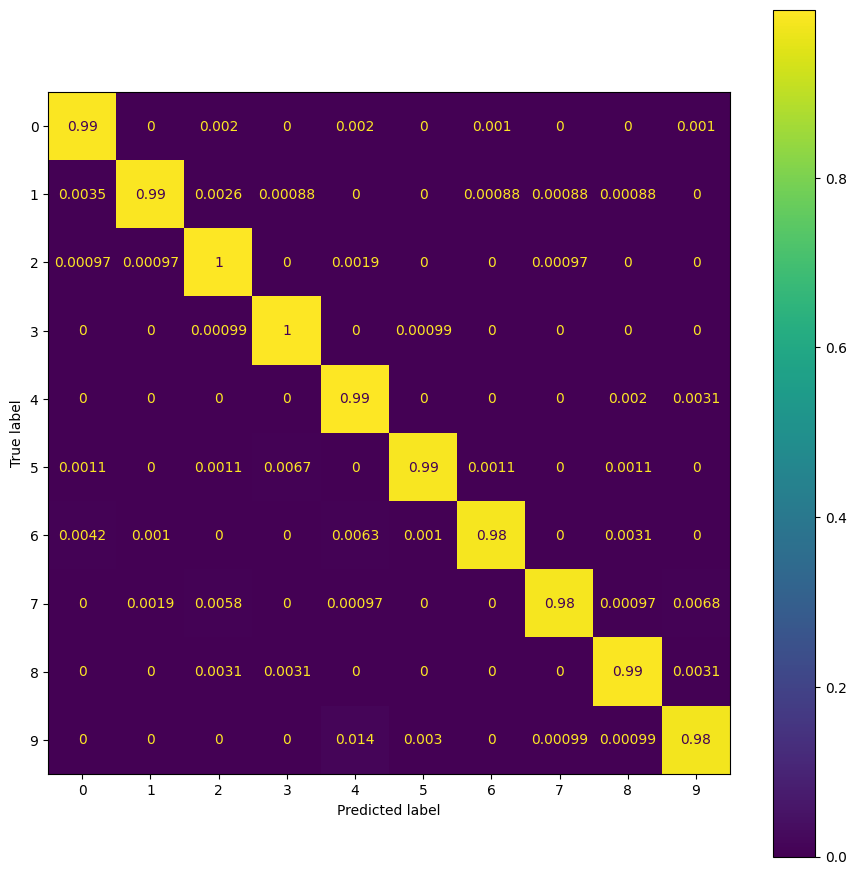

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
%matplotlib inline
prediction_y = model.predict(test_X)
pred_y = np.argmax(prediction_y, axis = 1)
cm = confusion_matrix(np.argmax(test_y,axis = 1),pred_y, normalize='true')
plt.rcParams['figure.figsize'] = [11, 11]
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1,2,3,4,5,6,7,8,9])
disp.plot()
plt.show()
print(classification_report(np.argmax(test_y,axis = 1),pred_y))

# <font color=blue>Stage 5: Viewing filters and feature maps </font>

# <font color=blue> A- Viewing filters (kernels)

#### On a affiché le nom de nos différentes couches avec la taille des filtres associés.

In [ ]:
import matplotlib.pyplot as plt

from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.preprocessing import image


for layer in model.layers :
  if 'conv' not in layer.name :
    continue
  filters , biases = layer.get_weights()
  print(layer.name, filters.shape)

conv2d_3 (3, 3, 1, 20)
conv2d_4 (3, 3, 20, 30)
conv2d_5 (3, 3, 30, 65)


#### On constate bien que la taille de notre filtre pour la 1ere couche est $(3, 3, 1, 20)$

In [ ]:
filters , biases = model.layers[1].get_weights()
print(filters.shape)


(3, 3, 1, 20)


#### Nous avons normalisé nos filtres

In [ ]:
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

#### On réalise l'affichage de nos 6 premiers filtres. On visualise donc les poids.

#### La sortie nous donne bien des 06 premiers filtres de notre couche. Nous avons des images en niveau gris. Les zones blanches sont pour les poids positifs forts et les zones noires sont pour les poids négaitfs fort.

#### On est à la 1ere couche dont on détecte grâce à ses filtres des caractéristiques élémentaires sur les images. Nous avons des images de nos filtres qui ne sont pas uniformes. Le modèle a donc ajusté les filtres aux images contenus dans notre dataset.

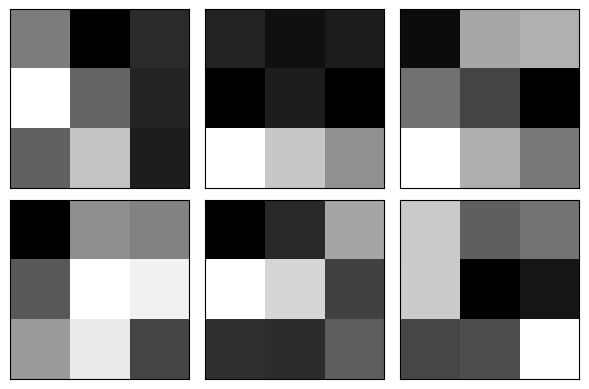

In [ ]:
import matplotlib.pyplot as plt
n_filters = 6
ix = 1

num_rows_display = (n_filters + 2) // 3
num_cols_display = 3

plt.figure(figsize=(num_cols_display * 2, num_rows_display * 2))
for i in range(n_filters):
  f = filters[:, :, :, i]
  for j in range(f.shape[2]):
    ax = plt.subplot(num_rows_display, num_cols_display, ix)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.imshow(f[:, :, j], cmap='gray')
    ix += 1
plt.tight_layout()
plt.show()


# <font color=blue> B- Viewing features maps

#### On regarde le résulat qu'on obtient après l'application de nos filtres sur les images de notre dataset.

#### En utilisant le modèle pour faire des prédictions, nous obtenons la taille de notre feature qui est $(2, 7, 7, 65)$. Nous avons le 2 qui correspond aux 02 images que nous avons traîtés. Le $(7*7)$ correspond à la taille de l'image après les MaxPooling sur notre image de $28*28$. Le 65 c'est le nombre de filtres dans la couche.

In [ ]:
from keras.utils import img_to_array


from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


image = train_X[7:9]
img = image
model2 = Model(inputs = model.inputs , outputs = model.layers[8].output , name = 'feature_map')


feature = model2.predict(img)
print(feature.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
(2, 7, 7, 65)


#### En visualisant la sortie après application des filtres, nous avons des images qui se présentent sous formes de signaux un peu abstraits. Les 65 cartes réagissent chacunes à un motif précis qui est nécessaire à la classification finale.

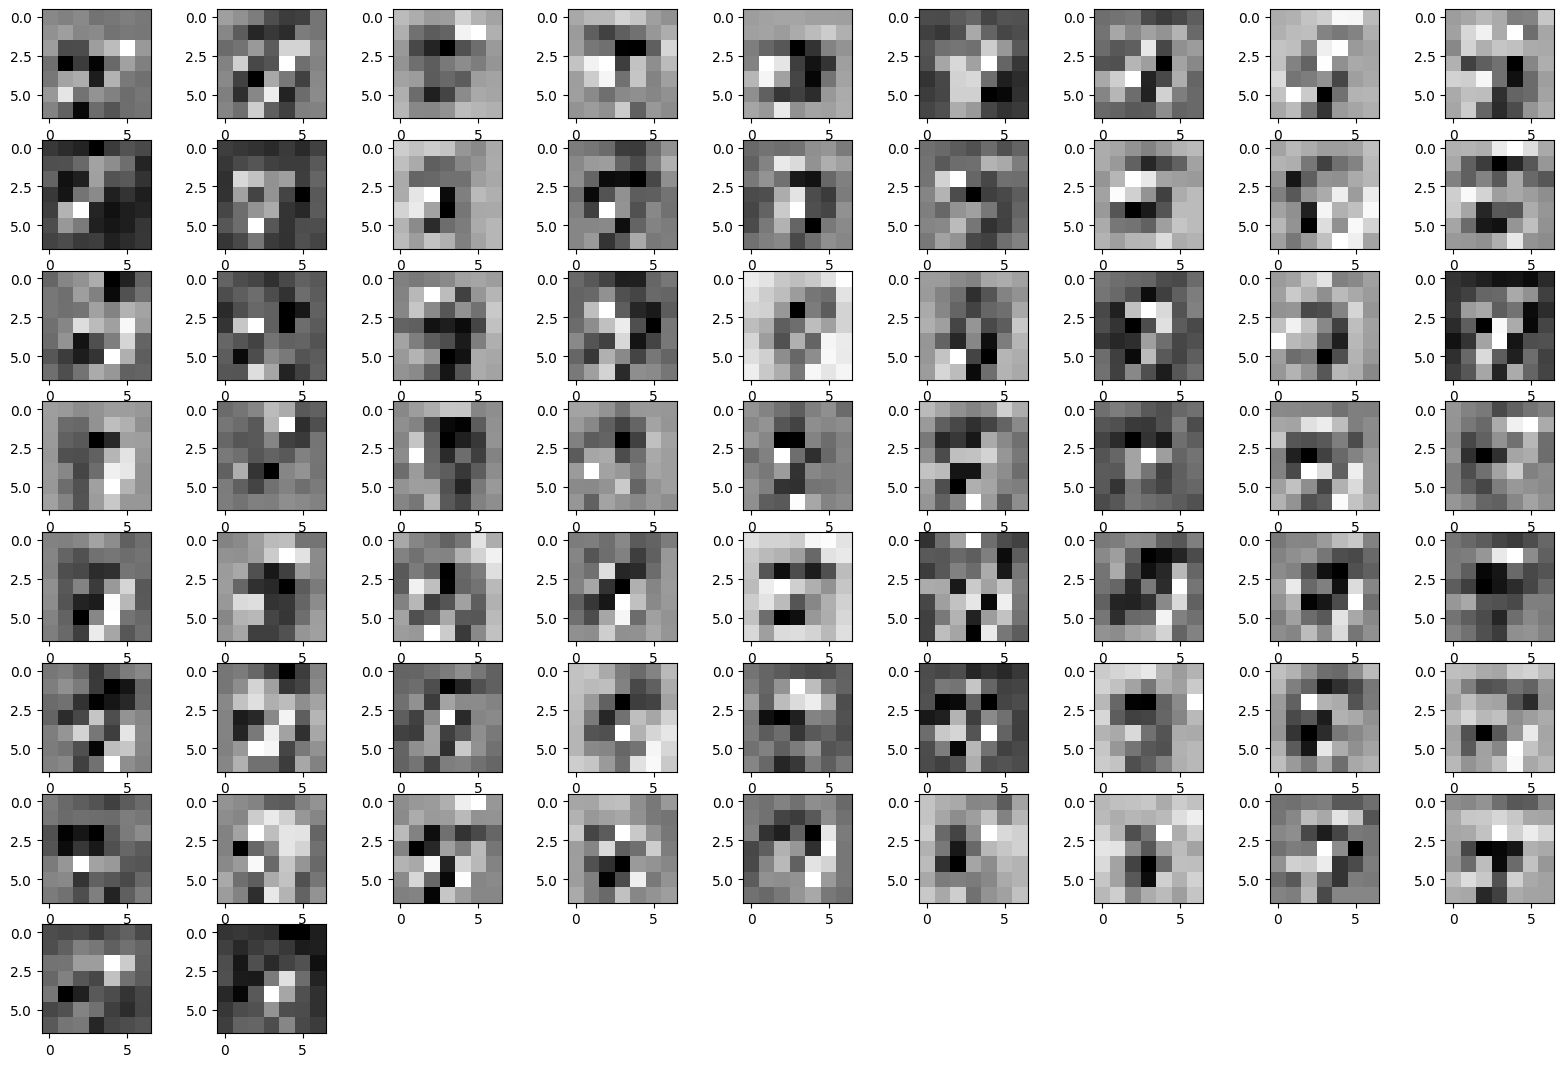

In [ ]:
fig = plt.figure(figsize=(20,15))

for i in range(1,feature.shape[3]+1):

    plt.subplot(9,9,i)
    plt.imshow(feature[0,:,:,i-1] , cmap='gray')

plt.show()

### Conclusion

#### Ce tp nous a permis de comprendre le principe de l'overfitting et comment y pallier en utilisant les techniques de régularisation telles que la data augmentation, la regularization L2, le dropout et les cnn.
#### Aussi, il nous a permis de comprendre le principe de filtrage des images au niveau des cnn.